# Importing Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import nltk
nltk.download('omw-1.4')
from tensorflow import keras
from gensim.models import Word2Vec
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import PunktSentenceTokenizer
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


# Reading File

In [ ]:
read_file = pd.read_table('source_tweets.txt')
read_file.to_csv (r'source_tweets.csv', index=None)
dataset_1 = pd.read_csv('source_tweets.csv')
print(dataset_1)

      731166399389962242  \
0     714598641827246081   
1     691809004356501505   
2     693204708933160960   
3     551099691702956032   
4     767223774072676354   
...                  ...   
1484  692004901455556608   
1485  760109079133990912   
1486  500281131057811456   
1487  523098334421319680   
1488  523545090099523584   

     🔥ca kkk grand wizard 🔥 endorses @hillaryclinton #neverhillary #trump2016 URL  
0     an open letter to trump voters from his top st...                            
1     america is a nation of second chances —@potus ...                            
2     brandon marshall visits and offers advice, sup...                            
3     rip elly may clampett: so sad to learn #beverl...                            
4     former 3 doors down guitarist matt roberts has...                            
...                                                 ...                            
1484  .@potus just announced new reforms to address ...                    

In [ ]:
read_file = pd.read_table('label.txt')
read_file.to_csv (r'label.csv', index=None)
dataset_2 = pd.read_csv('label.csv',sep=':')
print(dataset_2)

      unverified  731166399389962242
0     unverified  714598641827246081
1      non-rumor  691809004356501505
2      non-rumor  693204708933160960
3           true  551099691702956032
4      non-rumor  767223774072676354
...          ...                 ...
1484   non-rumor  692004901455556608
1485  unverified  760109079133990912
1486  unverified  500281131057811456
1487       false  523098334421319680
1488  unverified  523545090099523584

[1489 rows x 2 columns]


In [ ]:
headerList = ['answer','sourceid']
dataset_2.to_csv("label.csv", header=headerList, index=False)
dataset_2 = pd.read_csv("label.csv")
print(dataset_2.head())
print()
headerList = ['sourceid','review']
dataset_1.to_csv("source_tweets.csv", header=headerList, index=False)
dataset_1 = pd.read_csv("source_tweets.csv")
print(dataset_1.head())

       answer            sourceid
0  unverified  714598641827246081
1   non-rumor  691809004356501505
2   non-rumor  693204708933160960
3        true  551099691702956032
4   non-rumor  767223774072676354

             sourceid                                             review
0  714598641827246081  an open letter to trump voters from his top st...
1  691809004356501505  america is a nation of second chances —@potus ...
2  693204708933160960  brandon marshall visits and offers advice, sup...
3  551099691702956032  rip elly may clampett: so sad to learn #beverl...
4  767223774072676354  former 3 doors down guitarist matt roberts has...


In [ ]:
# dataset = pd.concat(map(pd.read_csv, ['source_tweets.csv', 'label.csv']),axis=1)
dataset=pd.merge(dataset_1,dataset_2,on='sourceid')

#counting total number of words
print(sum(dataset['review'].str.count(' ')))
#counting no of unique words
print(dataset['review'].nunique())

21566
1427


In [ ]:
dataset.head()
print(len(dataset))

1489


In [ ]:
dataset.head()

,sourceid,review,answer
0,714598641827246081,an open letter to trump voters from his top st...,unverified
1,691809004356501505,america is a nation of second chances —@potus ...,non-rumor
2,693204708933160960,"brandon marshall visits and offers advice, sup...",non-rumor
3,551099691702956032,rip elly may clampett: so sad to learn #beverl...,true
4,767223774072676354,former 3 doors down guitarist matt roberts has...,non-rumor


# Data Preprocessing

In [ ]:
print((dataset['review'].str.count(' ')))

0       12
1       15
2       15
3       15
4       17
        ..
1484    13
1485     4
1486    17
1487     4
1488    11
Name: review, Length: 1489, dtype: int64


In [ ]:
print(dataset.columns)

Index(['sourceid', 'review', 'answer'], dtype='object')


In [ ]:
#Total Number of words
print(sum(dataset['review'].str.count(' ')))

21566


In [ ]:
mlcorpus=[]
dlcorpus=[]
for i in range(len(dataset)):
  review = re.sub('[^a-zA-Z]', ' ', dataset['review'][i])
  review = review.lower()
  review = review.split()
  lemmatizer = WordNetLemmatizer()
  all_stopwords = stopwords.words('english')
  review = [lemmatizer.lemmatize(word) for word in review if not word in set(all_stopwords)]
  dlcorpus.append(review)
  review=' '.join(review)
  dataset['review'][i]=review
  mlcorpus.append(review)

<ipython-input-11-c5ad0aba2c1b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['review'][i]=review


In [ ]:
#List containing length of each sequence in the data set
len_list=[len(i.split(" ")) for i in dataset['review']]

In [ ]:
#List of all words in the data set
word_list=[j  for i in dataset['review'] for j in i.split(" ")]

In [ ]:
vocab_size=len(list(set(word_list)))
print(vocab_size)

4180


In [ ]:
print(word_list)

['open', 'letter', 'trump', 'voter', 'top', 'strategist', 'turned', 'defector', 'url', 'via', 'xojanedotcom', 'america', 'nation', 'second', 'chance', 'potus', 'new', 'reform', 'solitary', 'confinement', 'url', 'url', 'brandon', 'marshall', 'visit', 'offer', 'advice', 'support', 'brother', 'fallen', 'hero', 'zaevion', 'dobson', 'url', 'url', 'rip', 'elly', 'may', 'clampett', 'sad', 'learn', 'beverlyhillbillies', 'star', 'donna', 'douglas', 'passed', 'away', 'url', 'former', 'door', 'guitarist', 'matt', 'robert', 'died', 'age', 'according', 'father', 'url', 'url', 'craigslist', 'ad', 'get', 'paid', 'hour', 'protest', 'trump', 'rally', 'url', 'url', 'missing', 'afghan', 'soldier', 'found', 'trying', 'enter', 'canada', 'near', 'niagara', 'fall', 'url', 'url', 'day', 'ferguson', 'cop', 'told', 'dirty', 'bloody', 'lie', 'via', 'thedailybeast', 'url', 'url', 'riphulkhogan', 'heart', 'ripping', 'like', 'shirt', 'wwe', 'miss', 'chick', 'fil', 'manager', 'allegedly', 'banned', 'hilarious', 'lis

In [ ]:
#Total no. of words
len(word_list)

16073

In [ ]:
#finding Count of each word
from collections import Counter
word_len=[len(i) for i in word_list]
cl=Counter(word_list)
clen=Counter(word_len)
print(cl)
print(clen)

Counter({'url': 1925, 'shot': 108, 'say': 104, 'ferguson': 91, 'police': 85, 'paul': 81, 'walker': 78, 'u': 68, 'died': 66, 'report': 66, 'year': 62, 'isi': 56, 'obama': 54, 'one': 53, 'new': 51, 'breaking': 51, 'death': 48, 'dead': 47, 'ottawa': 46, 'man': 46, 'soldier': 45, 'war': 45, 'memorial': 45, 'woman': 45, 'killed': 43, 'shooting': 43, 'news': 42, 'trump': 39, 'people': 38, 'p': 36, 'photo': 35, 'via': 34, 'american': 34, 'first': 34, 'day': 33, 'state': 33, 'potus': 32, 'still': 32, 'banksy': 32, 'mh': 31, 'hand': 31, 'official': 31, 'suspect': 31, 'parliament': 29, 'black': 28, 'two': 27, 'video': 27, 'dy': 26, 'world': 26, 'old': 26, 'attack': 26, 'arrested': 26, 'letter': 25, 'get': 25, 'rt': 25, 'shooter': 25, 'shoot': 25, 'president': 25, 'million': 25, 'make': 25, 'found': 24, 'car': 24, 'national': 24, 'spider': 24, 'gunman': 24, 'r': 24, 'islamic': 23, 'suicide': 23, 'canadian': 23, 'charliehebdo': 22, 'fast': 22, 'today': 22, 'leader': 22, 'target': 22, 'may': 21, 's

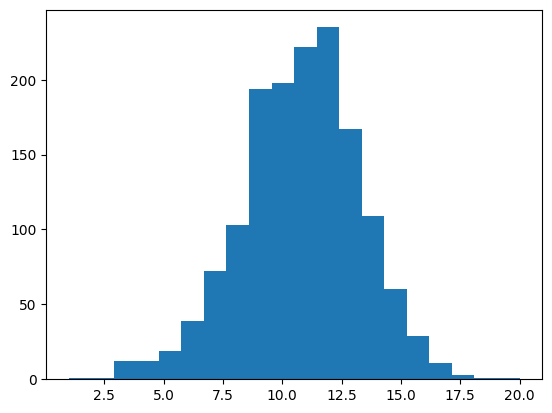

In [ ]:
from matplotlib import pyplot as plt

plt.hist(len_list, bins=20)

plt.show()

# Converting Text into Numbers

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 1500,binary=True)
x = cv.fit_transform(mlcorpus).toarray()

In [ ]:
from sklearn.preprocessing import LabelEncoder
y=dataset['answer']
le = LabelEncoder()
y = le.fit_transform(y)
print(y)

[3 1 1 ... 3 0 3]


In [ ]:
y.shape

(1489,)

# Splitting data into train-test split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

# Training Machine Learning Model

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[66  7  3  4]
 [ 5 41 21  8]
 [ 1  0 64  6]
 [ 2  6 10 54]]


0.7550335570469798

In [ ]:
x=np.array(dataset['review'])

In [ ]:
maxlen=15
embedding_dim = 150

In [ ]:
print(x)

['open letter trump voter top strategist turned defector url via xojanedotcom'
 'america nation second chance potus new reform solitary confinement url url'
 'brandon marshall visit offer advice support brother fallen hero zaevion dobson url url'
 ...
 'breaking news according document released press mikebrown connected earlier robbery ferguson url'
 'ebola vaccine url news today'
 'concerned airport passenger suit homemade hazmat flight url url']


In [ ]:
#prepare a tokenizer for reviews
x_tokenizer = Tokenizer(num_words=vocab_size, oov_token=None)
x_tokenizer.fit_on_texts(x)
print(x_tokenizer)
#convert text sequences into integer sequences
x_seq    =   x_tokenizer.texts_to_sequences(x)
print(x_seq)
word_index=x_tokenizer.word_index

[[260, 53, 28, 423, 261, 262, 424, 589, 1, 32, 1264], [219, 1265, 1266, 1267, 37, 15, 726, 923, 924, 1, 1], [1934, 1935, 925, 350, 1936, 220, 727, 1268, 425, 1937, 1938, 1, 1], [110, 351, 75, 590, 426, 591, 1939, 76, 263, 264, 926, 352, 1], [177, 1269, 1270, 1271, 1940, 9, 353, 427, 1272, 1, 1], [1273, 354, 54, 196, 221, 178, 28, 927, 1, 1], [84, 111, 21, 61, 222, 928, 112, 85, 728, 297, 1, 1], [35, 4, 143, 428, 1941, 1942, 1274, 32, 1943, 1, 1], [1275, 355, 1944, 90, 505, 1945, 1946], [197, 223, 198, 929, 506, 1276, 265, 356, 357, 1, 1], [67, 429, 144, 358, 128, 159, 113, 1, 1277, 1], [1947, 1948, 55, 930, 931, 31, 359, 199, 360, 507, 298, 729, 1], [40, 1, 1], [56, 38, 932, 730, 21, 2, 19, 22, 23, 933, 934, 44, 1278, 96, 731], [10, 33, 1949, 1950, 430, 1951, 11, 1952, 935, 145, 1, 1], [24, 4, 2, 592, 129, 508, 361, 1953, 1954, 10, 732, 1], [10, 936, 362, 260, 34, 1279, 363, 15, 733, 1], [509, 3, 1280, 593, 1955, 299, 937, 1956, 200, 1957, 179, 1, 431, 1], [130, 130, 300, 77, 36, 1281,

In [ ]:
#padding zero upto maximum length
x=pad_sequences(x_seq, maxlen=maxlen, padding='post', truncating='post')
#size of vocabulary ( +1 for padding token)
#vocab_size   =  len(x_tokenizer.word_index) + 1
vocab_size+=1

In [ ]:
print(vocab_size)

4181


# Word Embedding

In [ ]:
print(dlcorpus)

[['open', 'letter', 'trump', 'voter', 'top', 'strategist', 'turned', 'defector', 'url', 'via', 'xojanedotcom'], ['america', 'nation', 'second', 'chance', 'potus', 'new', 'reform', 'solitary', 'confinement', 'url', 'url'], ['brandon', 'marshall', 'visit', 'offer', 'advice', 'support', 'brother', 'fallen', 'hero', 'zaevion', 'dobson', 'url', 'url'], ['rip', 'elly', 'may', 'clampett', 'sad', 'learn', 'beverlyhillbillies', 'star', 'donna', 'douglas', 'passed', 'away', 'url'], ['former', 'door', 'guitarist', 'matt', 'robert', 'died', 'age', 'according', 'father', 'url', 'url'], ['craigslist', 'ad', 'get', 'paid', 'hour', 'protest', 'trump', 'rally', 'url', 'url'], ['missing', 'afghan', 'soldier', 'found', 'trying', 'enter', 'canada', 'near', 'niagara', 'fall', 'url', 'url'], ['day', 'ferguson', 'cop', 'told', 'dirty', 'bloody', 'lie', 'via', 'thedailybeast', 'url', 'url'], ['riphulkhogan', 'heart', 'ripping', 'like', 'shirt', 'wwe', 'miss'], ['chick', 'fil', 'manager', 'allegedly', 'banned'

In [ ]:
word2vec_model = Word2Vec(dlcorpus, vector_size=embedding_dim, min_count = 1, window = 5)
word_model=word2vec_model.wv
word_base=word_model.key_to_index

In [ ]:
print(word_model)

KeyedVectors<vector_size=150, 4180 keys>


In [ ]:
print(word_base)

{'url': 0, 'shot': 1, 'say': 2, 'ferguson': 3, 'police': 4, 'paul': 5, 'walker': 6, 'u': 7, 'report': 8, 'died': 9, 'year': 10, 'isi': 11, 'obama': 12, 'one': 13, 'breaking': 14, 'new': 15, 'death': 16, 'dead': 17, 'man': 18, 'ottawa': 19, 'war': 20, 'memorial': 21, 'soldier': 22, 'woman': 23, 'killed': 24, 'shooting': 25, 'news': 26, 'trump': 27, 'people': 28, 'p': 29, 'photo': 30, 'via': 31, 'first': 32, 'american': 33, 'day': 34, 'state': 35, 'banksy': 36, 'still': 37, 'potus': 38, 'official': 39, 'mh': 40, 'suspect': 41, 'hand': 42, 'parliament': 43, 'black': 44, 'video': 45, 'two': 46, 'attack': 47, 'dy': 48, 'arrested': 49, 'old': 50, 'world': 51, 'million': 52, 'get': 53, 'rt': 54, 'shoot': 55, 'letter': 56, 'make': 57, 'shooter': 58, 'president': 59, 'car': 60, 'spider': 61, 'r': 62, 'national': 63, 'gunman': 64, 'found': 65, 'canadian': 66, 'islamic': 67, 'suicide': 68, 'fast': 69, 'leader': 70, 'target': 71, 'today': 72, 'charliehebdo': 73, 'star': 74, 'clinton': 75, 'furious

In [ ]:
embedding_matrix = np.zeros((len(word_base) + 1, embedding_dim))
for word in word_base:
    embedding_vector = word_model[word]
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[word_index[word]] = embedding_vector

In [ ]:
print(embedding_matrix.shape)

(4181, 150)


In [ ]:
word_model.most_similar(positive=["letter"])

[('url', 0.9371373653411865),
 ('new', 0.9339432716369629),
 ('obama', 0.9326991438865662),
 ('death', 0.932354211807251),
 ('u', 0.9306519627571106),
 ('isi', 0.93061763048172),
 ('still', 0.9303678274154663),
 ('shooting', 0.9299939274787903),
 ('dead', 0.9296255707740784),
 ('killed', 0.9294467568397522)]

In [ ]:
#Splitting into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.10,random_state=42,shuffle=True)

In [ ]:
#Splitting into train and validation sets
X_train, X_val, y_train, y_val=train_test_split(X_train,y_train,test_size=0.10,random_state=42,shuffle=True)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(1206, 15)
(1206,)
(134, 15)
(134,)
(149, 15)
(149,)


In [ ]:
from keras.utils.vis_utils import plot_model
from numpy import array
from keras import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Flatten, Dropout, Embedding, GlobalMaxPooling1D, Reshape
from keras.layers import LSTM
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import concatenate
from tensorflow.keras import regularizers

# Training Deep Learning Model

In [ ]:
def define_model(length, vocab_size):
    # channel 1
    inputs1 = Input(shape=(length,))
    print(inputs1)
    embedding1 = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=length)(inputs1)
    conv1 = Conv1D(filters=150, kernel_size=3, activation='relu', padding='valid')(embedding1)
    drop1 = Dropout(0.3)(conv1)
    pool1 = GlobalMaxPooling1D()(drop1)
    flat1 = Flatten()(pool1)
    # channel 2
    inputs2 = Input(shape=(length,))
    print(inputs2)
    embedding2 = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=length)(inputs2)
    conv2 = Conv1D(filters=150, kernel_size=4, activation='relu', padding='valid')(embedding2)
    drop2 = Dropout(0.3)(conv2)
    pool2 = GlobalMaxPooling1D()(drop2)
    flat2 = Flatten()(pool2)
    # channel 3
    inputs3 = Input(shape=(length,))
    print(inputs3)
    embedding3 = Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=length)(inputs3)
    conv3 = Conv1D(filters=150, kernel_size=5, activation='relu', padding='valid')(embedding3)
    drop3 = Dropout(0.3)(conv3)
    pool3 = GlobalMaxPooling1D()(drop3)
    flat3 = Flatten()(pool3)
    # merge
    print(flat1.shape)
    print(flat2.shape)
    print(flat3.shape)
    merged = concatenate([flat1, flat2, flat3])
    print(merged.shape)
    # interpretation
    dense1 = Dense(450, activation='relu')(merged)
    dense2= Dense(50, activation='relu')(dense1)
    outputs = Dense(4, activation='softmax')(dense2)
    model = Model(inputs=[inputs1, inputs2, inputs3], outputs=outputs)

    return model

In [ ]:
vocab_size

4181

In [ ]:
# define model
model = define_model(maxlen,vocab_size)

KerasTensor(type_spec=TensorSpec(shape=(None, 15), dtype=tf.float32, name='input_4'), name='input_4', description="created by layer 'input_4'")
KerasTensor(type_spec=TensorSpec(shape=(None, 15), dtype=tf.float32, name='input_5'), name='input_5', description="created by layer 'input_5'")
KerasTensor(type_spec=TensorSpec(shape=(None, 15), dtype=tf.float32, name='input_6'), name='input_6', description="created by layer 'input_6'")
(None, 150)
(None, 150)
(None, 150)
(None, 450)


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 15)]         0           []                               
                                                                                                  
 input_5 (InputLayer)           [(None, 15)]         0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 15)]         0           []                               
                                                                                                  
 embedding_3 (Embedding)        (None, 15, 150)      627150      ['input_4[0][0]']                
                                                                                            

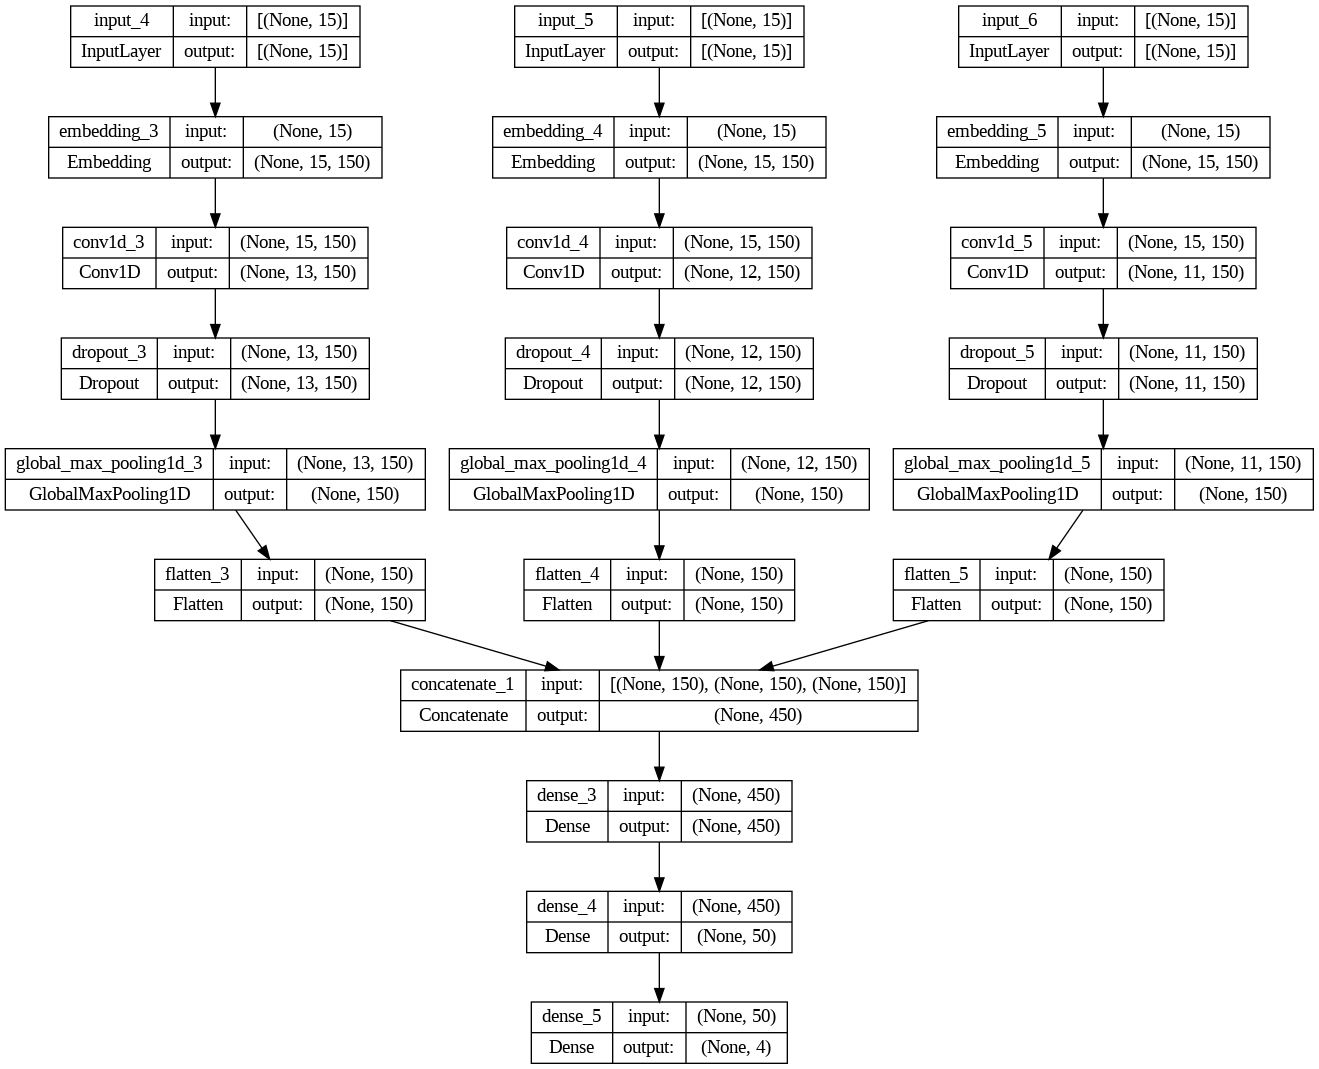

In [ ]:
# compile
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['sparse_categorical_accuracy'])
# summarize
print(model.summary())
plot_model(model, show_shapes=True, to_file='multichannel.png')

In [ ]:
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint, TensorBoard
es = EarlyStopping(monitor='val_loss', mode='min', patience=5,  restore_best_weights=True)
best_model = ModelCheckpoint("cnn_best.h5", monitor='val_sparse_categorical_accuracy', verbose=0, save_best_only=True)

In [ ]:
# fit model
history=model.fit([X_train,X_train,X_train], array(y_train),
                  epochs=50,
                  verbose=True,
                  callbacks=[best_model, es],
                  validation_data=([X_val,X_val,X_val], y_val),
                  batch_size=16)

Epoch 1/50
76/76 [==============================] - 3s 21ms/step - loss: 1.3603 - sparse_categorical_accuracy: 0.3167 - val_loss: 1.1711 - val_sparse_categorical_accuracy: 0.4403
Epoch 2/50
76/76 [==============================] - 1s 19ms/step - loss: 0.5981 - sparse_categorical_accuracy: 0.7720 - val_loss: 0.7166 - val_sparse_categorical_accuracy: 0.7910
Epoch 3/50
76/76 [==============================] - 1s 18ms/step - loss: 0.0654 - sparse_categorical_accuracy: 0.9743 - val_loss: 0.9904 - val_sparse_categorical_accuracy: 0.7537
Epoch 4/50
76/76 [==============================] - 1s 19ms/step - loss: 0.0071 - sparse_categorical_accuracy: 0.9983 - val_loss: 0.8849 - val_sparse_categorical_accuracy: 0.7836
Epoch 5/50
76/76 [==============================] - 2s 22ms/step - loss: 9.2949e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.9238 - val_sparse_categorical_accuracy: 0.7761
Epoch 6/50
76/76 [==============================] - 2s 22ms/step - loss: 4.7484e-04 - sparse_categori

In [ ]:
model.load_weights('cnn_best.h5')

Text(0.5, 1.0, 'Training and Validation loss')

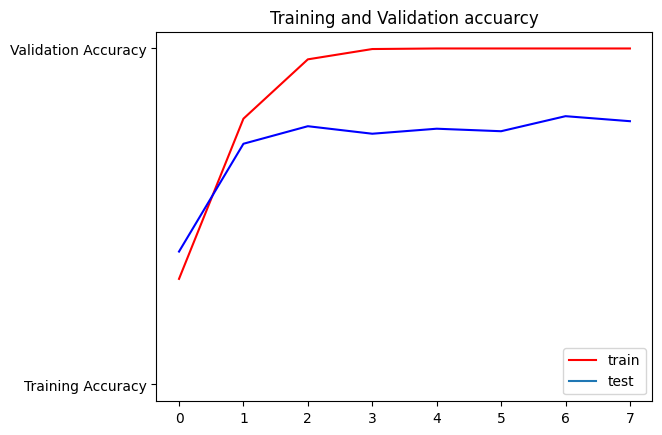

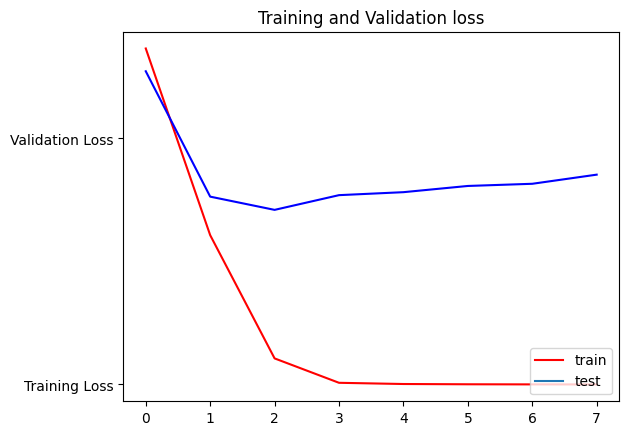

In [ ]:
acc=history.history['sparse_categorical_accuracy']
val_acc=history.history['val_sparse_categorical_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc))

plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and Validation accuarcy')
plt.legend(['train', 'test'], loc='lower right')
plt.figure()

plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.legend(['train', 'test'], loc='lower right')
plt.title('Training and Validation loss')


# Evaluation of Accuracy

In [ ]:
y_hat=model.predict([X_test,X_test,X_test])

5/5 [==============================] - 0s 5ms/step


In [ ]:
y_hat_sent=[np.argmax(i) for i in y_hat]

In [ ]:
print(y_hat_sent)

[2, 1, 3, 0, 1, 3, 0, 1, 1, 2, 2, 0, 1, 3, 2, 2, 0, 2, 3, 1, 0, 2, 1, 3, 0, 2, 2, 0, 1, 2, 3, 0, 2, 2, 2, 1, 3, 3, 3, 1, 1, 3, 1, 2, 1, 0, 1, 1, 1, 2, 0, 2, 2, 0, 2, 0, 2, 0, 3, 1, 3, 1, 3, 3, 2, 3, 0, 0, 3, 0, 0, 2, 2, 0, 0, 0, 2, 0, 3, 0, 2, 2, 2, 2, 0, 3, 2, 1, 1, 1, 3, 1, 3, 2, 1, 3, 2, 2, 1, 2, 1, 1, 0, 0, 3, 3, 1, 3, 0, 3, 2, 1, 3, 0, 0, 1, 3, 1, 2, 3, 0, 2, 0, 0, 3, 1, 0, 2, 1, 3, 3, 2, 0, 3, 1, 0, 0, 3, 3, 3, 2, 2, 0, 1, 0, 1, 0, 0, 2]


In [ ]:
# y_test=y_test.tolist()

In [ ]:
print(y_test)

[2 1 0 1 3 3 0 2 0 2 2 0 0 2 2 2 0 2 3 1 0 2 1 3 0 2 2 0 1 2 3 0 2 2 2 1 3
 3 3 1 1 3 3 2 1 0 1 1 3 2 0 2 2 0 2 0 2 0 3 1 3 1 3 0 1 3 0 2 1 0 3 2 2 0
 0 0 2 3 1 0 2 2 2 2 0 3 2 2 1 1 3 1 0 2 1 2 2 2 0 2 1 1 3 0 3 3 1 3 0 3 2
 1 3 0 0 1 3 1 2 2 0 2 0 0 3 1 1 2 1 3 3 2 0 3 0 3 0 2 3 3 2 2 0 1 0 3 0 2
 2]


In [ ]:
from itertools import chain
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

#This part is for the confusion matrix and accuracy score
cf_matrix = confusion_matrix(y_test, y_hat_sent)
print ('Confusion Matrix :')
print(cf_matrix)
print ('Accuracy Score :',accuracy_score(y_test, y_hat_sent))
print ('Report : ')
print (classification_report(y_test, y_hat_sent) )


Confusion Matrix :
[[31  4  0  3]
 [ 2 25  1  2]
 [ 2  2 39  4]
 [ 4  4  0 26]]
Accuracy Score : 0.8120805369127517
Report : 
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        38
           1       0.71      0.83      0.77        30
           2       0.97      0.83      0.90        47
           3       0.74      0.76      0.75        34

    accuracy                           0.81       149
   macro avg       0.81      0.81      0.81       149
weighted avg       0.82      0.81      0.82       149

